# **EMG Gesture Classification using Machine Learning**
This notebook classifies 4 hand gestures (Rock, Scissors, Paper, OK) 
using EMG signal data with multiple ML models

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. DATA LOADING


In [2]:
# Define file paths for the 4 gesture classes
file_paths = [
    '/kaggle/input/emg-4/0.csv',  # Rock
    '/kaggle/input/emg-4/1.csv',  # Scissors
    '/kaggle/input/emg-4/2.csv',  # Paper
    '/kaggle/input/emg-4/3.csv'   # OK
]

# Load and combine all CSV files
dfs = []
for path in file_paths:
    # Read CSV without header
    df = pd.read_csv(path, header=None)
    
    # Create feature column names (f0, f1, ..., f63) + label
    feature_cols = [f"f{i}" for i in range(df.shape[1]-1)]
    col_names = feature_cols + ['label']
    df.columns = col_names
    
    dfs.append(df)

# Concatenate all dataframes
Data = pd.concat(dfs, axis=0).reset_index(drop=True)

# Shuffle the data for better training
Data = Data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Shape of concatenated DataFrame:", Data.shape)
print("\nFirst 5 rows:")
print(Data.head())

Shape of concatenated DataFrame: (11678, 65)

First 5 rows:
     f0    f1   f2    f3    f4    f5    f6    f7    f8    f9  ...   f55   f56  \
0  -1.0   1.0 -1.0   4.0  11.0  23.0   3.0   5.0   1.0  -3.0  ...  26.0  -3.0   
1   0.0  -1.0  1.0   1.0   7.0  40.0  -4.0  -2.0   2.0  -2.0  ...  -7.0  -1.0   
2   1.0  -6.0 -1.0  -4.0  -6.0  13.0  -6.0  21.0 -24.0 -17.0  ... -22.0  -3.0   
3  12.0   7.0  3.0  11.0  12.0  -8.0   6.0   9.0   5.0  -9.0  ...   8.0  -3.0   
4   8.0  25.0  1.0  11.0   2.0   0.0 -22.0   6.0   7.0 -32.0  ...  -4.0  31.0   

    f57   f58   f59   f60   f61   f62   f63  label  
0  -1.0  -4.0  -6.0  -9.0 -31.0 -10.0  -5.0      3  
1   1.0  -5.0   3.0   2.0  10.0   5.0  -2.0      3  
2   5.0   0.0  -9.0  14.0   5.0 -30.0  20.0      0  
3  -4.0  13.0   4.0 -15.0 -53.0  -3.0  -8.0      2  
4  56.0   2.0 -15.0 -10.0 -46.0   0.0  20.0      0  

[5 rows x 65 columns]


## 2. EXPLORATORY DATA ANALYSIS (EDA)



DATA STATISTICS
                 f0            f1            f2            f3            f4  \
count  11678.000000  11678.000000  11678.000000  11678.000000  11678.000000   
mean      -0.520380     -0.726837     -0.739082     -0.729748     -0.159103   
std       18.566709     11.766878      4.989944      7.441675     17.850402   
min     -116.000000   -104.000000    -33.000000    -75.000000   -121.000000   
25%       -9.000000     -4.000000     -3.000000     -4.000000    -10.000000   
50%       -1.000000     -1.000000     -1.000000     -1.000000      0.000000   
75%        7.000000      3.000000      2.000000      3.000000     10.000000   
max      111.000000     90.000000     34.000000     55.000000     92.000000   

                 f5            f6            f7            f8            f9  \
count  11678.000000  11678.000000  11678.000000  11678.000000  11678.000000   
mean      -0.554890     -1.272649     -0.661843     -0.665953     -0.654222   
std       25.809528     25.089972 

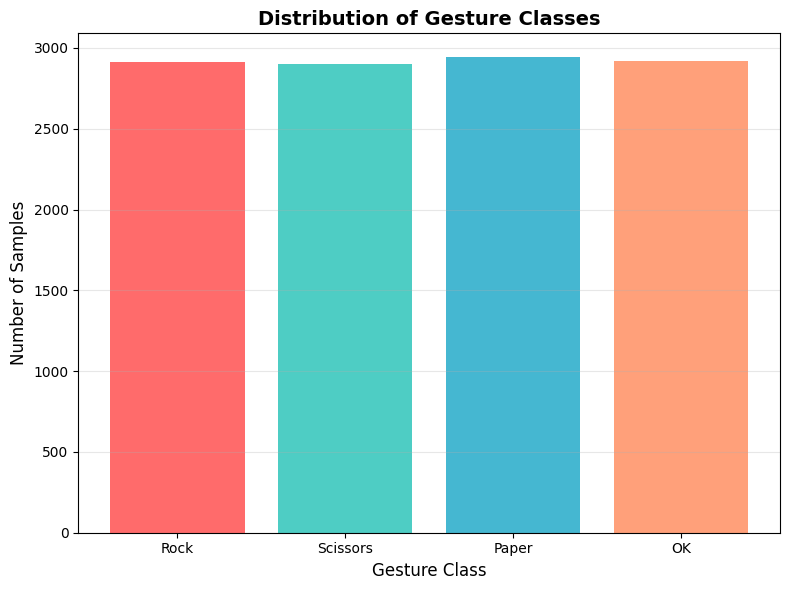

In [3]:
print("\n" + "="*80)
print("DATA STATISTICS")
print("="*80)
print(Data.describe())

print("\n" + "="*80)
print("DATA INFO")
print("="*80)
Data.info()

# Check for missing values
print("\n" + "="*80)
print("MISSING VALUES CHECK")
print("="*80)
print(f"Total missing values: {Data.isnull().sum().sum()}")

# Visualize class distribution
class_counts = Data['label'].value_counts().sort_index()
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.title('Distribution of Gesture Classes', fontsize=14, fontweight='bold')
plt.xlabel('Gesture Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks([0, 1, 2, 3], ['Rock', 'Scissors', 'Paper', 'OK'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. DATA PREPARATION


In [4]:
# Separate features (X) and target labels (y)
X = Data.drop(columns=['label'])
y = Data['label']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution in train/test splits
)

# Feature scaling (important for SVM, MLP, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("DATA SPLIT SUMMARY")
print("="*80)
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")



DATA SPLIT SUMMARY
Training samples: 9342
Testing samples: 2336
Number of features: 64


## 4. MODEL EVALUATION FUNCTION


In [5]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evaluate a trained model on both training and testing data.
    Displays confusion matrices and classification reports.
    """
    print("\n" + "="*80)
    print(f"{model_name.upper()} - EVALUATION RESULTS")
    print("="*80)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"\n{model_name} Accuracy - Train: {train_acc:.4f}")
    print(f"{model_name} Accuracy - Test:  {test_acc:.4f}")
    
    # Confusion Matrix - Training Data
    cm_train = confusion_matrix(y_train, y_train_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, 
                                        display_labels=['Rock', 'Scissors', 'Paper', 'OK'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp_train.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'{model_name} - Confusion Matrix (Training Data)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n{model_name} - Classification Report (Training Data):")
    print(classification_report(y_train, y_train_pred, 
                                target_names=['Rock', 'Scissors', 'Paper', 'OK']))
    
    # Confusion Matrix - Test Data
    cm_test = confusion_matrix(y_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, 
                                       display_labels=['Rock', 'Scissors', 'Paper', 'OK'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp_test.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'{model_name} - Confusion Matrix (Test Data)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n{model_name} - Classification Report (Test Data):")
    print(classification_report(y_test, y_test_pred, 
                                target_names=['Rock', 'Scissors', 'Paper', 'OK']))
    
    return train_acc, test_acc

## 5. MODEL 1: MULTI-LAYER PERCEPTRON (MLP) NEURAL NETWORK



TRAINING MODEL 1: MLP NEURAL NETWORK

MLP NEURAL NETWORK - EVALUATION RESULTS

MLP Neural Network Accuracy - Train: 0.9909
MLP Neural Network Accuracy - Test:  0.9238


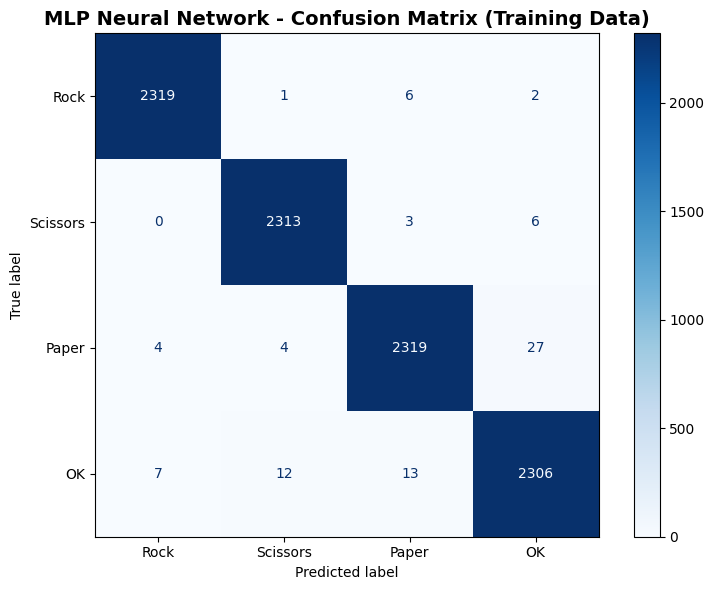


MLP Neural Network - Classification Report (Training Data):
              precision    recall  f1-score   support

        Rock       1.00      1.00      1.00      2328
    Scissors       0.99      1.00      0.99      2322
       Paper       0.99      0.99      0.99      2354
          OK       0.99      0.99      0.99      2338

    accuracy                           0.99      9342
   macro avg       0.99      0.99      0.99      9342
weighted avg       0.99      0.99      0.99      9342



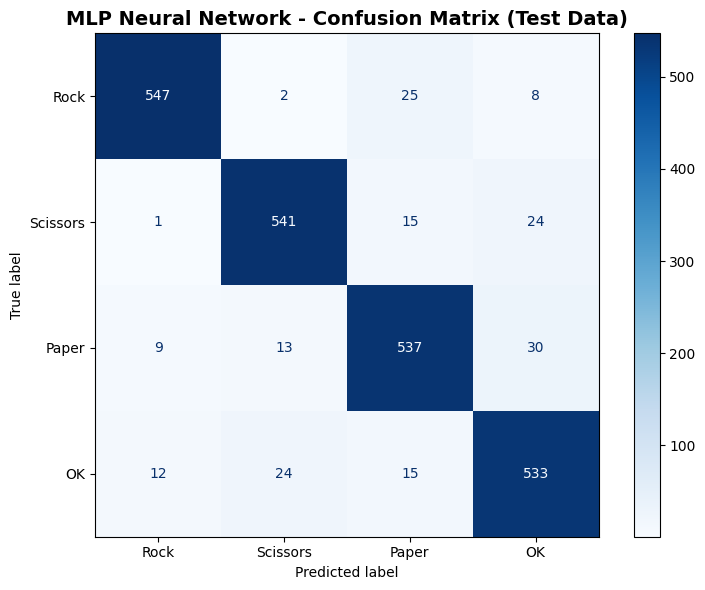


MLP Neural Network - Classification Report (Test Data):
              precision    recall  f1-score   support

        Rock       0.96      0.94      0.95       582
    Scissors       0.93      0.93      0.93       581
       Paper       0.91      0.91      0.91       589
          OK       0.90      0.91      0.90       584

    accuracy                           0.92      2336
   macro avg       0.92      0.92      0.92      2336
weighted avg       0.92      0.92      0.92      2336



In [6]:

print("\n" + "="*80)
print("TRAINING MODEL 1: MLP NEURAL NETWORK")
print("="*80)

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers with 100 and 50 neurons
    activation='relu',              # ReLU activation function
    solver='adam',                  # Adam optimizer
    max_iter=1000,                  # Maximum iterations
    random_state=42,
    early_stopping=True,            # Stop if no improvement
    validation_fraction=0.1,        # 10% for validation
    n_iter_no_change=20             # Stop after 20 iterations without improvement
)

mlp.fit(X_train_scaled, y_train)
mlp_train_acc, mlp_test_acc = evaluate_model(mlp, X_train_scaled, X_test_scaled, 
                                              y_train, y_test, "MLP Neural Network")


## 6. MODEL 2: SUPPORT VECTOR MACHINE (SVM)



TRAINING MODEL 2: SUPPORT VECTOR MACHINE (SVM)

SVM - EVALUATION RESULTS

SVM Accuracy - Train: 0.9529
SVM Accuracy - Test:  0.9118


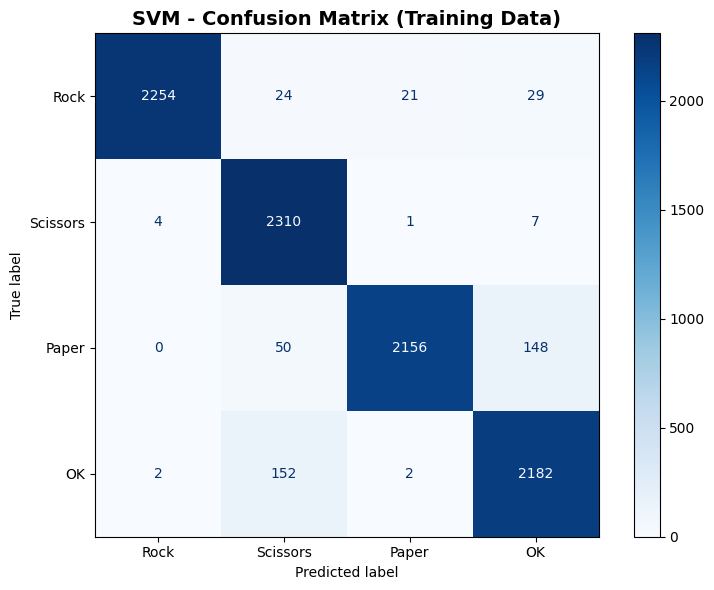


SVM - Classification Report (Training Data):
              precision    recall  f1-score   support

        Rock       1.00      0.97      0.98      2328
    Scissors       0.91      0.99      0.95      2322
       Paper       0.99      0.92      0.95      2354
          OK       0.92      0.93      0.93      2338

    accuracy                           0.95      9342
   macro avg       0.95      0.95      0.95      9342
weighted avg       0.95      0.95      0.95      9342



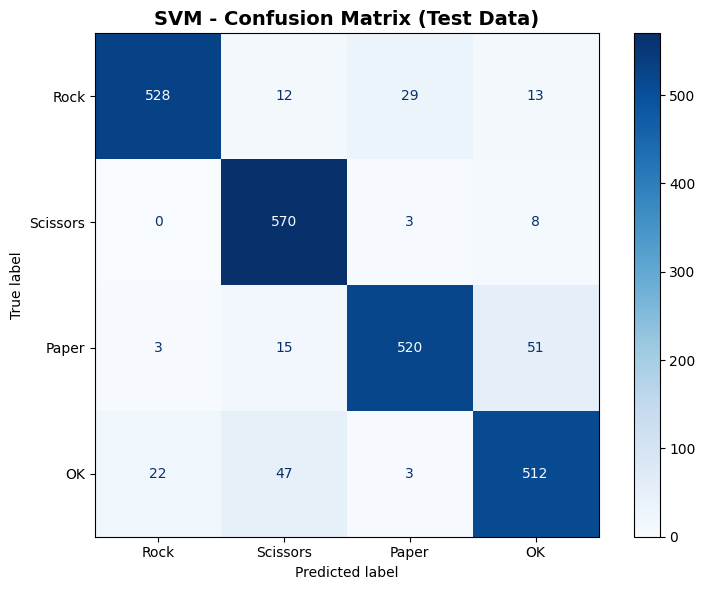


SVM - Classification Report (Test Data):
              precision    recall  f1-score   support

        Rock       0.95      0.91      0.93       582
    Scissors       0.89      0.98      0.93       581
       Paper       0.94      0.88      0.91       589
          OK       0.88      0.88      0.88       584

    accuracy                           0.91      2336
   macro avg       0.91      0.91      0.91      2336
weighted avg       0.91      0.91      0.91      2336



In [7]:
print("\n" + "="*80)
print("TRAINING MODEL 2: SUPPORT VECTOR MACHINE (SVM)")
print("="*80)

svm_model = SVC(
    kernel='rbf',      # Radial Basis Function kernel (good for non-linear data)
    C=1.0,             # Regularization parameter
    gamma='scale',     # Automatic gamma scaling
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_train_acc, svm_test_acc = evaluate_model(svm_model, X_train_scaled, X_test_scaled, 
                                              y_train, y_test, "SVM")


## 7. MODEL 3: LOGISTIC REGRESSION



TRAINING MODEL 3: LOGISTIC REGRESSION

LOGISTIC REGRESSION - EVALUATION RESULTS

Logistic Regression Accuracy - Train: 0.3851
Logistic Regression Accuracy - Test:  0.3493


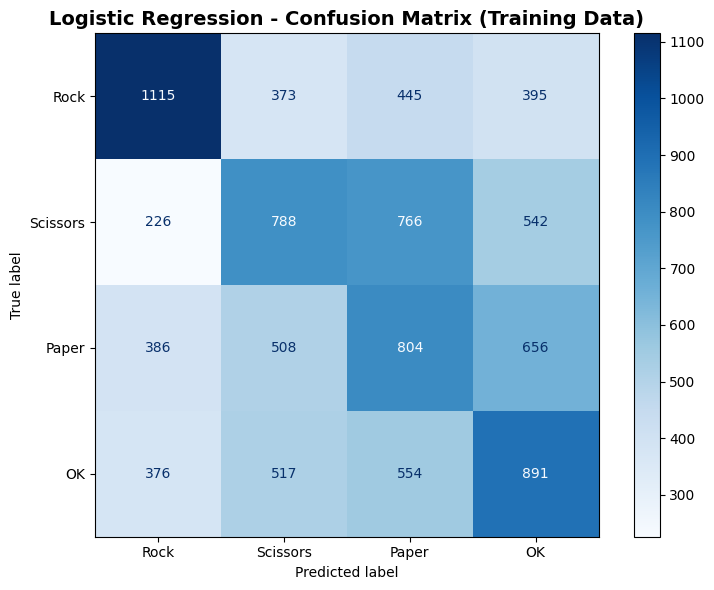


Logistic Regression - Classification Report (Training Data):
              precision    recall  f1-score   support

        Rock       0.53      0.48      0.50      2328
    Scissors       0.36      0.34      0.35      2322
       Paper       0.31      0.34      0.33      2354
          OK       0.36      0.38      0.37      2338

    accuracy                           0.39      9342
   macro avg       0.39      0.39      0.39      9342
weighted avg       0.39      0.39      0.39      9342



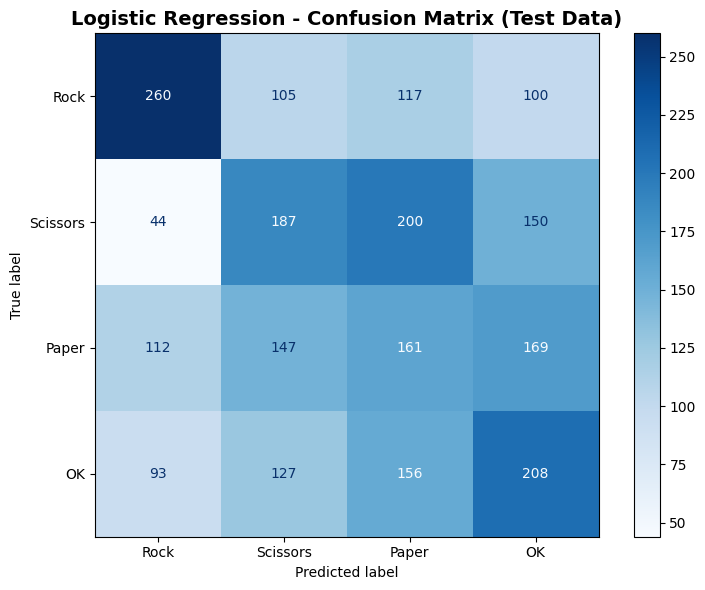


Logistic Regression - Classification Report (Test Data):
              precision    recall  f1-score   support

        Rock       0.51      0.45      0.48       582
    Scissors       0.33      0.32      0.33       581
       Paper       0.25      0.27      0.26       589
          OK       0.33      0.36      0.34       584

    accuracy                           0.35      2336
   macro avg       0.36      0.35      0.35      2336
weighted avg       0.36      0.35      0.35      2336



In [8]:
print("\n" + "="*80)
print("TRAINING MODEL 3: LOGISTIC REGRESSION")
print("="*80)

logreg = LogisticRegression(
    solver='lbfgs',     # Limited-memory BFGS optimizer
    max_iter=1000,      # Maximum iterations
    random_state=42
)

logreg.fit(X_train_scaled, y_train)
lr_train_acc, lr_test_acc = evaluate_model(logreg, X_train_scaled, X_test_scaled, 
                                            y_train, y_test, "Logistic Regression")


## 8. MODEL 4: RANDOM FOREST



TRAINING MODEL 4: RANDOM FOREST

RANDOM FOREST - EVALUATION RESULTS

Random Forest Accuracy - Train: 0.9373
Random Forest Accuracy - Test:  0.9165


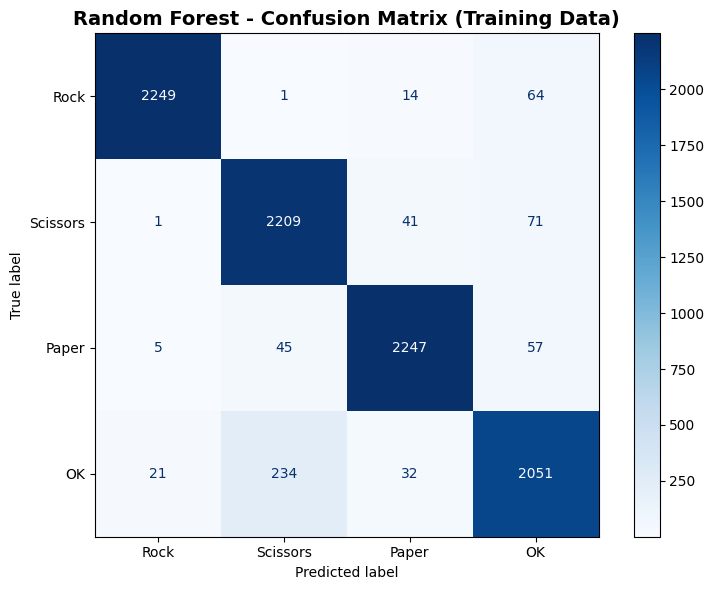


Random Forest - Classification Report (Training Data):
              precision    recall  f1-score   support

        Rock       0.99      0.97      0.98      2328
    Scissors       0.89      0.95      0.92      2322
       Paper       0.96      0.95      0.96      2354
          OK       0.91      0.88      0.90      2338

    accuracy                           0.94      9342
   macro avg       0.94      0.94      0.94      9342
weighted avg       0.94      0.94      0.94      9342



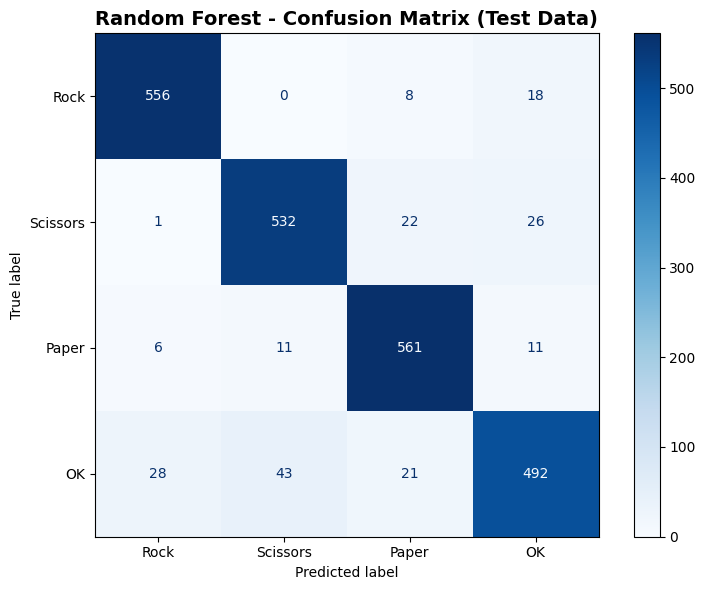


Random Forest - Classification Report (Test Data):
              precision    recall  f1-score   support

        Rock       0.94      0.96      0.95       582
    Scissors       0.91      0.92      0.91       581
       Paper       0.92      0.95      0.93       589
          OK       0.90      0.84      0.87       584

    accuracy                           0.92      2336
   macro avg       0.92      0.92      0.92      2336
weighted avg       0.92      0.92      0.92      2336



In [9]:
print("\n" + "="*80)
print("TRAINING MODEL 4: RANDOM FOREST")
print("="*80)

rf_model = RandomForestClassifier(
    n_estimators=150,        # Number of trees in the forest
    max_depth=12,            # Maximum depth of each tree
    max_features='sqrt',     # Number of features for best split
    min_samples_split=10,    # Minimum samples to split a node
    min_samples_leaf=5,      # Minimum samples per leaf
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

rf_model.fit(X_train_scaled, y_train)
rf_train_acc, rf_test_acc = evaluate_model(rf_model, X_train_scaled, X_test_scaled, 
                                            y_train, y_test, "Random Forest")


## 9. MODEL COMPARISON



FINAL MODEL COMPARISON
              Model  Train Accuracy  Test Accuracy  Overfitting Gap
 MLP Neural Network        0.990901       0.923801         0.067100
      Random Forest        0.937273       0.916524         0.020749
                SVM        0.952901       0.911815         0.041086
Logistic Regression        0.385142       0.349315         0.035827


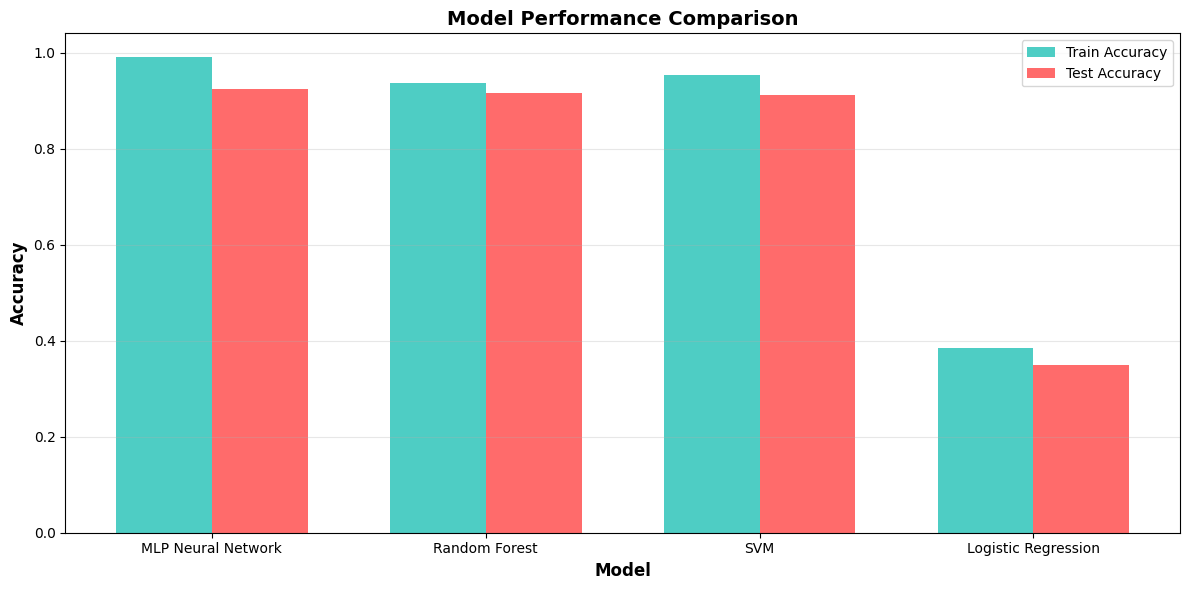


ANALYSIS COMPLETE!

Best Model: MLP Neural Network
Best Test Accuracy: 0.9238


In [10]:
print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['MLP Neural Network', 'SVM', 'Logistic Regression', 'Random Forest'],
    'Train Accuracy': [mlp_train_acc, svm_train_acc, lr_train_acc, rf_train_acc],
    'Test Accuracy': [mlp_test_acc, svm_test_acc, lr_test_acc, rf_test_acc]
})

comparison['Overfitting Gap'] = comparison['Train Accuracy'] - comparison['Test Accuracy']
comparison = comparison.sort_values('Test Accuracy', ascending=False)

print(comparison.to_string(index=False))

# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison['Train Accuracy'], width, label='Train Accuracy', color='#4ECDC4')
ax.bar(x + width/2, comparison['Test Accuracy'], width, label='Test Accuracy', color='#FF6B6B')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nBest Model: {comparison.iloc[0]['Model']}")
print(f"Best Test Accuracy: {comparison.iloc[0]['Test Accuracy']:.4f}")